In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("Caso_Pratico_base_churn_saas.csv")

df.head()

,id_cliente,tempo_contrato_meses,plano,regiao,logins_mes,tickets_suporte,valor_mensal,inadimplencia,qtd_funcionarios,uso_media_diaria_horas,churn
0,C001,12,Básico,Sudeste,15,2,120,0,3,1.8,0
1,C002,3,Premium,Sul,4,6,350,1,8,0.5,1
2,C003,8,Intermediário,Sudeste,10,1,210,0,5,1.2,0
3,C004,24,Premium,Centro-Oeste,25,0,370,0,12,3.5,0
4,C005,6,Básico,Nordeste,6,4,130,1,2,0.9,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              100 non-null    object 
 1   tempo_contrato_meses    100 non-null    int64  
 2   plano                   100 non-null    object 
 3   regiao                  100 non-null    object 
 4   logins_mes              100 non-null    int64  
 5   tickets_suporte         100 non-null    int64  
 6   valor_mensal            100 non-null    int64  
 7   inadimplencia           100 non-null    int64  
 8   qtd_funcionarios        100 non-null    int64  
 9   uso_media_diaria_horas  100 non-null    float64
 10  churn                   100 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 8.7+ KB


In [5]:
df.describe()

,tempo_contrato_meses,logins_mes,tickets_suporte,valor_mensal,inadimplencia,qtd_funcionarios,uso_media_diaria_horas,churn
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,9.690000,13.120000,2.570000,204.800000,0.420000,5.340000,1.729000,0.420000
std,6.107943,7.413174,2.370931,97.125141,0.496045,3.736849,1.045461,0.496045
min,1.000000,2.000000,0.000000,100.000000,0.000000,1.000000,0.200000,0.000000
25%,5.000000,6.000000,1.000000,115.000000,0.000000,2.000000,0.800000,0.000000
50%,9.000000,12.500000,1.500000,205.000000,0.000000,5.000000,1.650000,0.000000
75%,13.000000,19.000000,5.000000,240.000000,1.000000,7.000000,2.700000,1.000000
max,30.000000,29.000000,8.000000,400.000000,1.000000,15.000000,4.000000,1.000000


In [6]:
df.isnull().sum()

,0
id_cliente,0
tempo_contrato_meses,0
plano,0
regiao,0
logins_mes,0
tickets_suporte,0
valor_mensal,0
inadimplencia,0
qtd_funcionarios,0
uso_media_diaria_horas,0


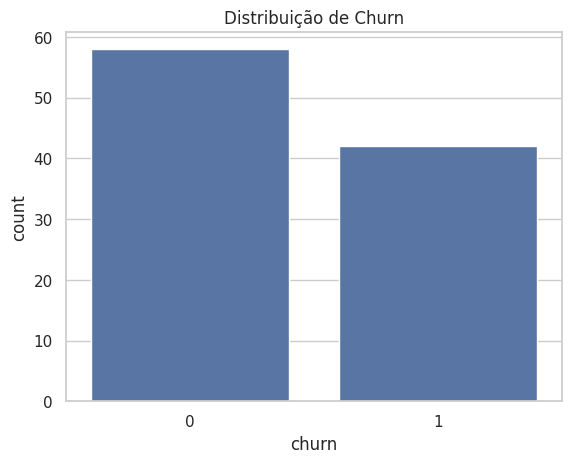

In [7]:
sns.countplot(x='churn', data=df)
plt.title("Distribuição de Churn")
plt.show()

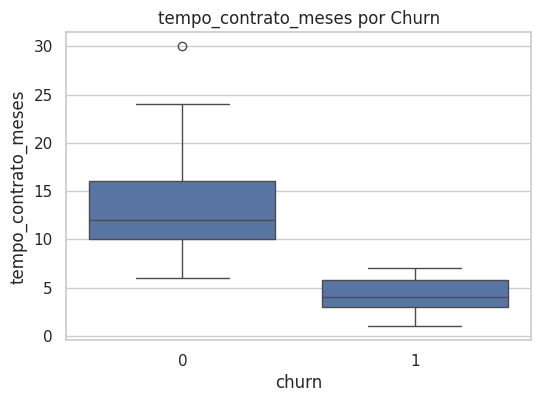

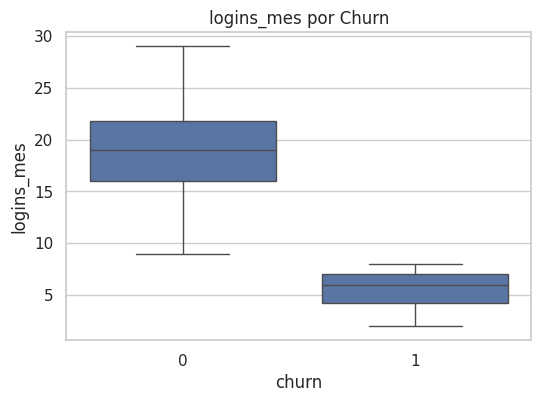

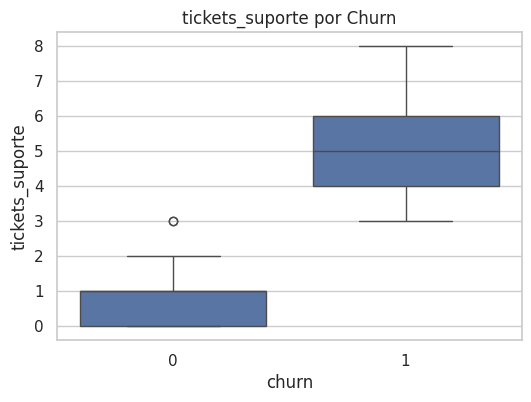

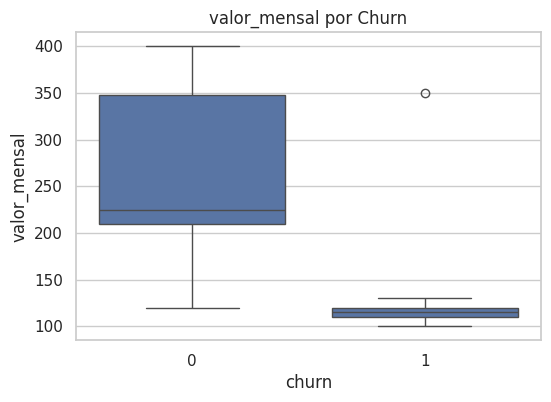

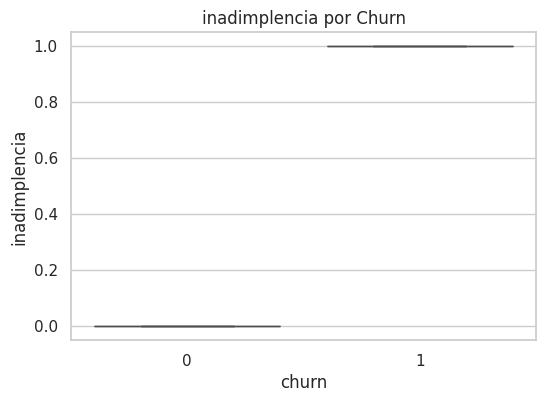

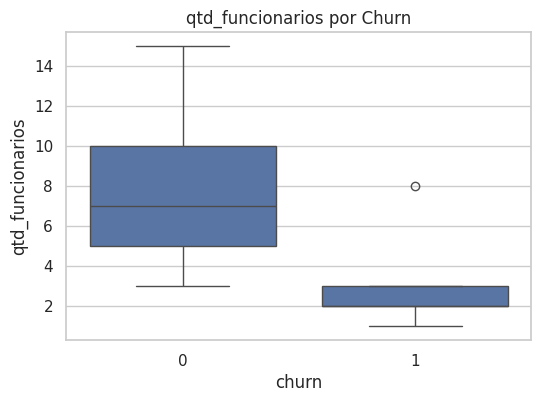

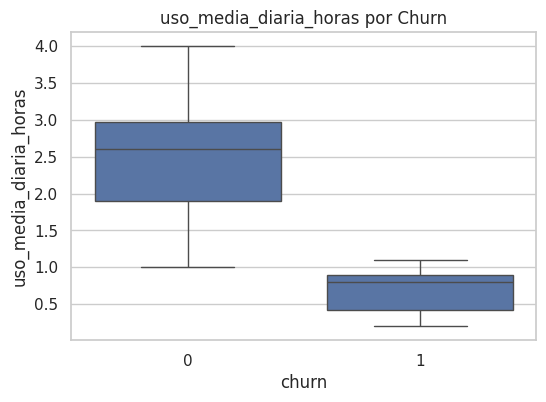

In [8]:
numericas = df.select_dtypes(include=np.number).columns

for col in numericas:
    if col != "churn":
        plt.figure(figsize=(6,4))
        sns.boxplot(x="churn", y=col, data=df)
        plt.title(f"{col} por Churn")
        plt.show()

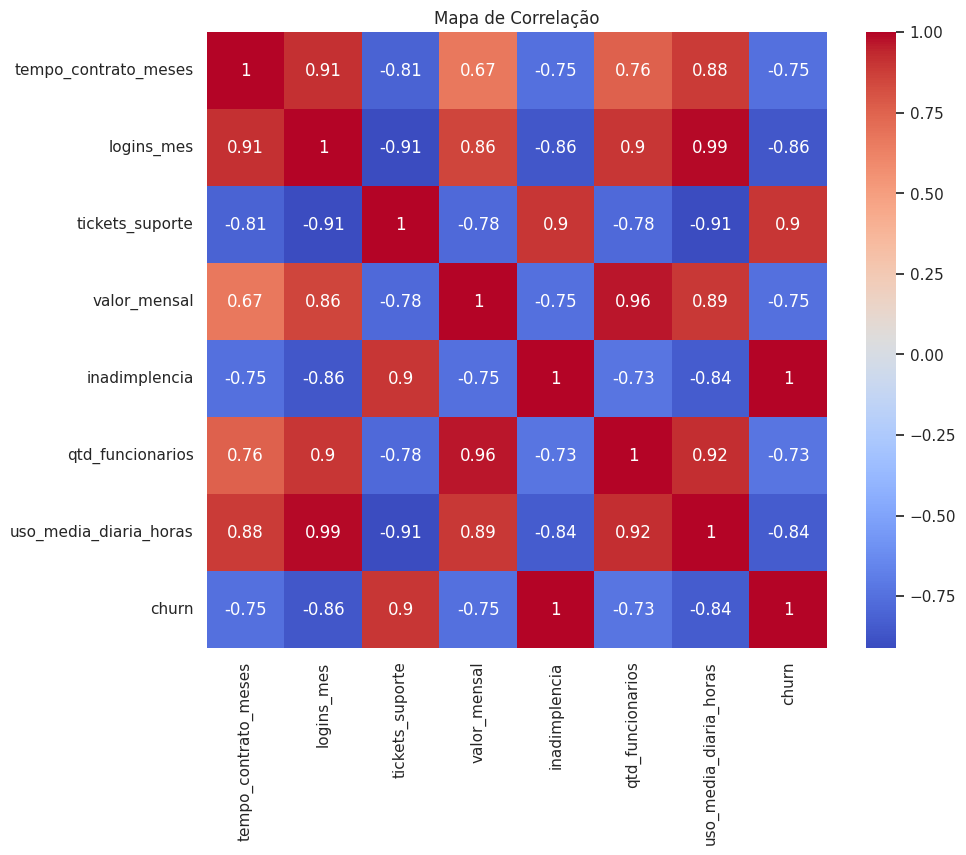

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Mapa de Correlação")
plt.show()

In [10]:
X = df.drop(columns=["churn", "id_cliente"])
y = df["churn"]

In [11]:
col_categoricas = X.select_dtypes(include="object").columns
col_numericas = X.select_dtypes(exclude="object").columns

In [12]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), col_numericas),
        ("cat", OneHotEncoder(drop="first"), col_categoricas)
    ]
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [14]:
pipeline_log = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", LogisticRegression())
])

pipeline_log.fit(X_train, y_train)
y_pred_log = pipeline_log.predict(X_test)
y_prob_log = pipeline_log.predict_proba(X_test)[:,1]

In [15]:
pipeline_rf = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(random_state=42))
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:,1]

In [16]:
pipeline_xgb = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ))
])

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:31:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [17]:
def avaliar_modelo(nome, y_test, y_pred, y_prob):
    print(f"\n===== {nome} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

In [18]:
avaliar_modelo("Regressão Logística", y_test, y_pred_log, y_prob_log)
avaliar_modelo("Random Forest", y_test, y_pred_rf, y_prob_rf)
avaliar_modelo("XGBoost", y_test, y_pred_xgb, y_prob_xgb)


===== Regressão Logística =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
ROC-AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


===== Random Forest =====
Accuracy: 0.9333333333333333
Precision: 0.8666666666666667
Recall: 1.0
F1-score: 0.9285714285714286
ROC-AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        17
           1       0.87      1.00      0.93        13

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30


===== XGBoost =====
Accuracy: 0.9
Precision: 0.8125
Re

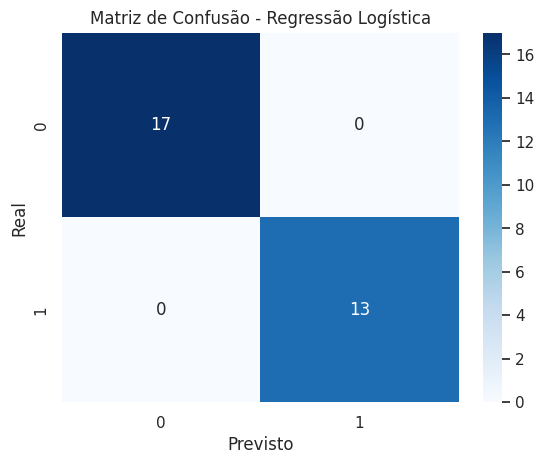

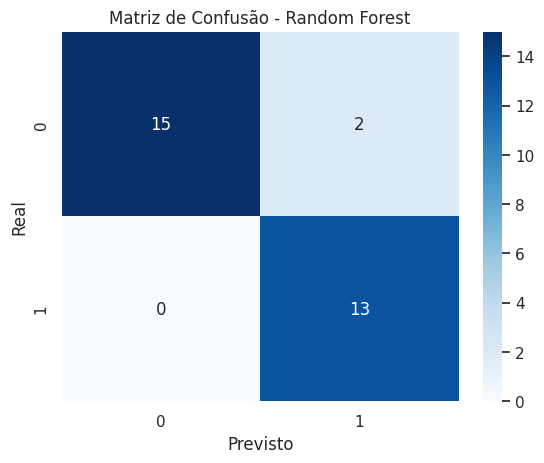

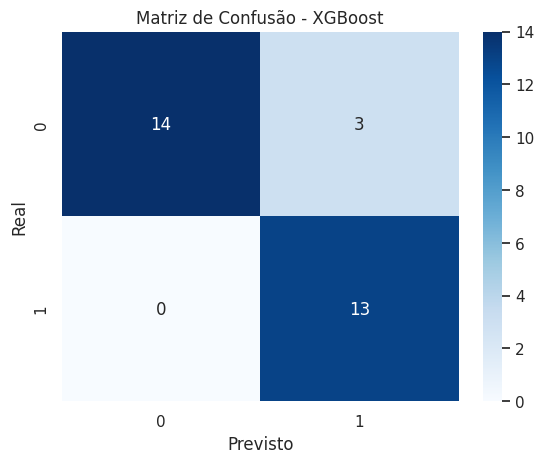

In [19]:
def plotar_matriz(y_test, y_pred, nome):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

plotar_matriz(y_test, y_pred_log, "Regressão Logística")
plotar_matriz(y_test, y_pred_rf, "Random Forest")
plotar_matriz(y_test, y_pred_xgb, "XGBoost")

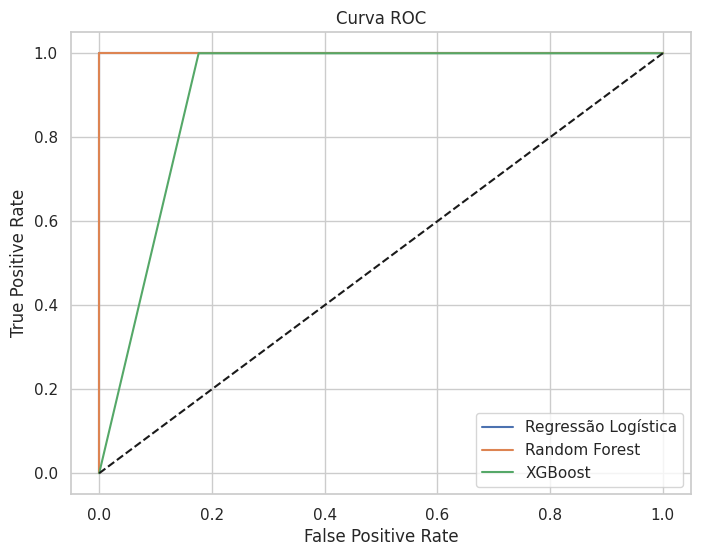

In [20]:
def plotar_roc(y_test, y_prob, nome):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=nome)

plt.figure(figsize=(8,6))

plotar_roc(y_test, y_prob_log, "Regressão Logística")
plotar_roc(y_test, y_prob_rf, "Random Forest")
plotar_roc(y_test, y_prob_xgb, "XGBoost")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [21]:
modelo_rf = pipeline_rf.named_steps["modelo"]

# Pegando nomes das colunas após OneHot
ohe = pipeline_rf.named_steps["preprocessamento"].named_transformers_["cat"]
colunas_ohe = ohe.get_feature_names_out(col_categoricas)

colunas_finais = list(col_numericas) + list(colunas_ohe)

importancias = modelo_rf.feature_importances_

df_importancia = pd.DataFrame({
    "variavel": colunas_finais,
    "importancia": importancias
}).sort_values(by="importancia", ascending=False)

df_importancia.head(10)

,variavel,importancia
1,logins_mes,0.214129
2,tickets_suporte,0.181711
4,inadimplencia,0.181081
6,uso_media_diaria_horas,0.177864
0,tempo_contrato_meses,0.118604
3,valor_mensal,0.063285
5,qtd_funcionarios,0.043875
7,plano_Intermediário,0.014499
8,plano_Premium,0.004443
10,regiao_Sudeste,0.000510
